In [5]:
import numpy as np
from scipy.interpolate import RegularGridInterpolator
import h5py
from tqdm import tqdm
from pyproj import Transformer
import rasterio as rio
import netCDF4 as nc
import matplotlib.pyplot as plt

In [6]:
GRID = h5py.File('Data/SOhi_meta/SOhi_v1_GRID_v8.mat')
XC = np.asarray(GRID['XC'][0,:])
XC = ((XC+ 180) %360) - 180

YC = np.asarray(GRID['YC'][:2344,0])

In [7]:
def find_index(latval, lonval):
    iy = np.argmin(abs(YC - latval))
    ix = np.argmin(abs(XC - lonval))

    return iy, ix

### SOhi to Rignot

In [40]:
cube = nc.Dataset('Data/melt_rates/rignot-2013/Ant_MeltingRate.v2.nc')
X = np.asarray(cube['xaxis'])
Y = np.asarray(cube['yaxis'])
testdata = np.asarray(cube['melt_actual'])

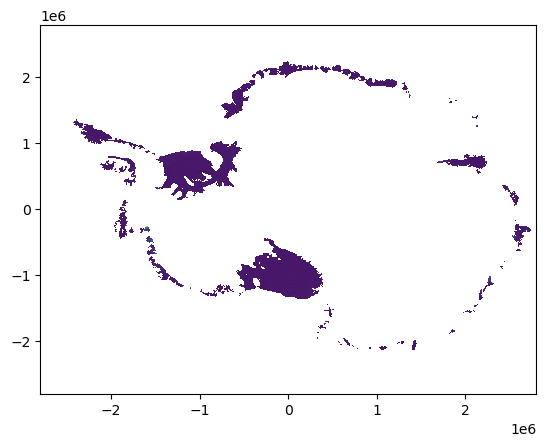

In [43]:
plt.pcolormesh(X, Y, testdata)

In [13]:
DATA = np.load('/Users/dinh/Desktop/Dinh_et_al_2026/Data/melt_rates/SOhi-v2/SOhi_v2_OctNovDec2007_MR.npy')
DATA = DATA * 60 * 60 * 24 * 365 / 917

In [55]:
transformer = Transformer.from_crs("EPSG:3031", "EPSG:4326")
transformer.transform(-1559524.9896543403, -274986.3327651498)

(-75.49999999999999, -100.0)

In [56]:
new_data = np.zeros((5601, 5601))
for x in tqdm(range(len(X))):
    for y in range(len(Y)):
        lat, lon = transformer.transform(X[x], Y[y])
        iy, ix = find_index(lat, lon)
        new_data[y, x] = DATA[iy, ix]

100%|███████████████████████████████████████| 5601/5601 [07:44<00:00, 12.06it/s]


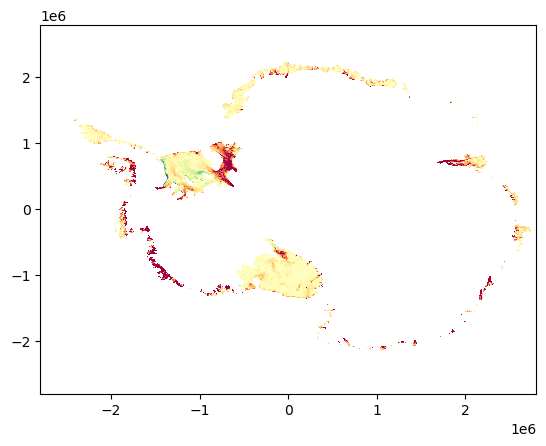

In [58]:
plt.pcolormesh(X, Y, -new_data, vmin = -10, vmax=10, cmap='Spectral_r')

In [63]:
new_data.shape, testdata.shape

((5601, 5601), (5601, 5601))

In [64]:
np.save('/Users/dinh/Desktop/Dinh_et_al_2026/Data/melt_rates/SOhi-v2/Resamp_RignotGrid.npy', new_data)

### Adusumilli

In [8]:
data = h5py.File('Data/melt_rates/adusumilli-2020/bb0448974g_3_1.h5')

In [9]:
X = np.asarray(data['x'][:,0])
Y = np.asarray(data['y'][:,0])
testdata = np.asarray(data['w_b'])

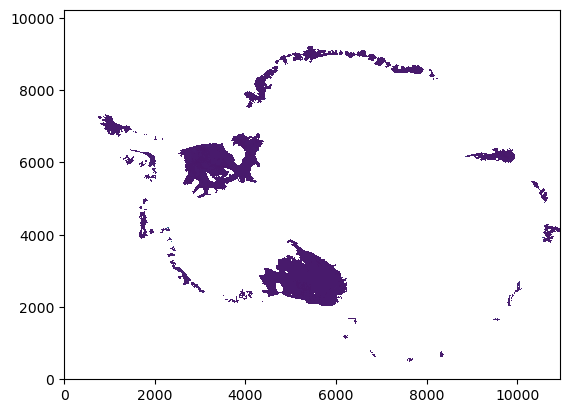

In [71]:
plt.pcolormesh(testdata)

In [10]:
transformer = Transformer.from_crs("EPSG:3031", "EPSG:4326")
transformer.transform(-1559524.9896543403, -274986.3327651498)

(-75.49999999999999, -100.0)

In [14]:
new_data = np.zeros((10229, 10941))
for x in tqdm(range(len(X))):
    for y in range(len(Y)):
        lat, lon = transformer.transform(X[x], Y[y])
        iy, ix = find_index(lat, lon)
        new_data[y, x] = DATA[iy, ix]

100%|█████████████████████████████████████| 10941/10941 [21:31<00:00,  8.47it/s]


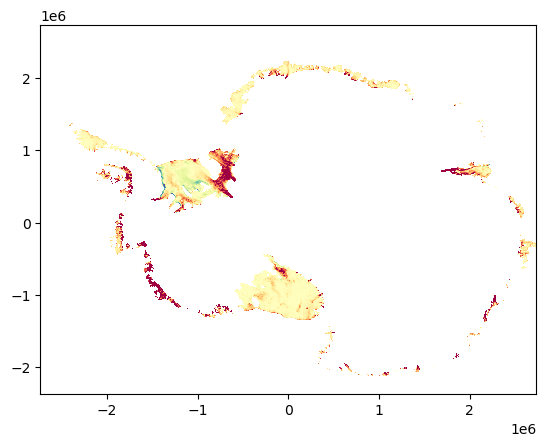

In [16]:
plt.pcolormesh(X, Y, -new_data, vmin = -10, vmax=10, cmap='Spectral_r')

In [17]:
np.save('/Users/dinh/Desktop/Dinh_et_al_2026/Data/melt_rates/SOhi-v2/Resamp_AdusumilliGrid.npy', new_data)